In [1]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Dense, Dropout, GlobalAveragePooling2D,
    Input, Concatenate, BatchNormalization
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint
from tensorflow.keras.regularizers import l2
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

IMG_SIZE   = 224
BATCH_SIZE = 16
NUM_STEM_FEATURES = 11  # one binary symptom question per class

# ── Change these paths to your actual folders ──────────────────────────
TRAIN_DIR = "G:/study/MP3/Dataset(N)/train/"   # must be a separate train folder
VAL_DIR   = "G:/study/MP3/Dataset(N)/val/"     # must be a separate val folder

In [2]:
# Training: augmentation ON
train_datagen = ImageDataGenerator(
    rescale          = 1./255,
    rotation_range   = 40,
    zoom_range       = 0.3,
    width_shift_range  = 0.3,
    height_shift_range = 0.3,
    shear_range      = 0.2,
    horizontal_flip  = True,
    fill_mode        = 'nearest'
)

# Validation: ONLY rescale — NO augmentation (this was a bug before)
val_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size = (IMG_SIZE, IMG_SIZE),
    batch_size  = BATCH_SIZE,
    class_mode  = 'categorical',
    shuffle     = True
)

val_gen = val_datagen.flow_from_directory(
    VAL_DIR,
    target_size = (IMG_SIZE, IMG_SIZE),
    batch_size  = BATCH_SIZE,
    class_mode  = 'categorical',
    shuffle     = False          # keep order for evaluation
)

class_labels = list(train_gen.class_indices.keys())
num_classes  = len(class_labels)
print("Classes detected:", class_labels)
print(f"Training samples: {train_gen.samples}  |  Val samples: {val_gen.samples}")



Found 5403 images belonging to 11 classes.
Found 1345 images belonging to 11 classes.
Classes detected: ['Banded Chlorosis', 'Brown Spot', 'BrownRust', 'Dried Leaves', 'Grassy shoot', 'Healthy Leaves', 'Pokkah Boeng', 'Sett Rot', 'Viral Disease', 'Yellow Leaf', 'smut']
Training samples: 5403  |  Val samples: 1345


In [3]:
class_weights_array = compute_class_weight(
    class_weight = 'balanced',
    classes      = np.unique(train_gen.classes),
    y            = train_gen.classes
)
class_weight_dict = dict(enumerate(class_weights_array))
print("\nClass weights (higher = underrepresented class gets more attention):")
for idx, label in enumerate(class_labels):
    print(f"  {label:25s}: {class_weight_dict[idx]:.3f}")


Class weights (higher = underrepresented class gets more attention):
  Banded Chlorosis         : 1.303
  Brown Spot               : 0.356
  BrownRust                : 1.949
  Dried Leaves             : 1.786
  Grassy shoot             : 1.773
  Healthy Leaves           : 1.428
  Pokkah Boeng             : 2.064
  Sett Rot                 : 0.941
  Viral Disease            : 0.925
  Yellow Leaf              : 0.514
  smut                     : 1.941


In [4]:
STEM_QUESTIONS = {
    "Banded Chlorosis" : "Do you see alternating yellow/green horizontal bands on leaves?",
    "Brown Spot"       : "Are there oval brown spots with yellow halos on the leaf surface?",
    "BrownRust"        : "Do you see powdery orange-brown pustules on the underside of leaves?",
    "Dried Leaves"     : "Are the leaf tips or entire leaves dried out and brown/papery?",
    "Grassy shoot"     : "Are there excessive thin, grass-like tillers/shoots at the base?",
    "Healthy Leaves"   : "Does the plant look uniformly green with no visible spots or wilting?",
    "Pokkah Boeng"     : "Is the top of the plant twisted, crinkled, or showing knife-cut lesions?",
    "Sett Rot"         : "Is the inside of the cane reddish, hollow, or giving a foul smell?",
    "Viral Disease"    : "Do you see mosaic/streaking patterns (mixed green-yellow patches) on leaves?",
    "Yellow Leaf"      : "Is the midrib of the leaf turning bright yellow?",
    "smut"             : "Do you see a whip-like black growth emerging from the top of the plant?"
}

def get_stem_inputs_interactive():
    """
    Ask one binary question per class (in class_labels order).
    Returns a numpy array of shape (1, NUM_STEM_FEATURES).
    """
    print("\n--- Stem / Visual Symptom Check ---")
    print("Answer each question with 1 (Yes) or 0 (No):\n")
    answers = []
    for label in class_labels:
        question = STEM_QUESTIONS.get(label, f"Is there any visible symptom related to {label}?")
        while True:
            try:
                ans = int(input(f"  [{label}] {question} (1/0): "))
                if ans in [0, 1]:
                    answers.append(ans)
                    break
                else:
                    print("  ⚠️  Please enter 1 (Yes) or 0 (No).")
            except ValueError:
                print("  ⚠️  Invalid input. Enter 1 or 0.")
    return np.array(answers, dtype=np.float32).reshape(1, -1)


In [5]:
# ── Branch 1: Leaf Image (CNN) ────────────────────────────────────────
leaf_input = Input(shape=(IMG_SIZE, IMG_SIZE, 3), name="leaf_input")
base_model = MobileNetV2(weights='imagenet', include_top=False,
                          input_tensor=leaf_input)

# FIX 3: Freeze first 120 layers (was 90 — too few for small dataset)
base_model.trainable = True
FINE_TUNE_AT = 120
for layer in base_model.layers[:FINE_TUNE_AT]:
    layer.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu',
           kernel_regularizer=l2(0.001))(x)   # FIX 6: L2 regularization
x = BatchNormalization()(x)
x = Dropout(0.5)(x)
leaf_features = Dense(128, activation='relu',
                        kernel_regularizer=l2(0.001))(x)

# ── Branch 2: Stem Symptoms (Dense) ──────────────────────────────────
stem_input    = Input(shape=(NUM_STEM_FEATURES,), name="stem_input")
s = Dense(32, activation='relu')(stem_input)
s = BatchNormalization()(s)
s = Dropout(0.3)(s)
stem_features = Dense(16, activation='relu')(s)

# ── Combine Both Branches ─────────────────────────────────────────────
combined = Concatenate()([leaf_features, stem_features])
combined = Dense(64, activation='relu',
                  kernel_regularizer=l2(0.001))(combined)
combined = Dropout(0.4)(combined)
output   = Dense(num_classes, activation='softmax')(combined)

# ── Final Model ───────────────────────────────────────────────────────
model = Model(inputs=[leaf_input, stem_input], outputs=output,
              name="HybridSugarcaneModel")

# FIX 4: Both callbacks now monitor the same metric (val_loss)
model.compile(
    optimizer = Adam(learning_rate=5e-5),
    loss      = 'categorical_crossentropy',
    metrics   = ['accuracy']
)
model.summary()


Model: "HybridSugarcaneModel"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 leaf_input (InputLayer)        [(None, 224, 224, 3  0           []                               
                                )]                                                                
                                                                                                  
 Conv1 (Conv2D)                 (None, 112, 112, 32  864         ['leaf_input[0][0]']             
                                )                                                                 
                                                                                                  
 bn_Conv1 (BatchNormalization)  (None, 112, 112, 32  128         ['Conv1[0][0]']                  
                                )                                              

In [6]:
class HybridGenerator(tf.keras.utils.Sequence):
    """
    Wraps an ImageDataGenerator to also generate random stem inputs
    during training (since we don't have real stem labels in the dataset).
    During real inference you supply actual answers interactively.

    Strategy: for training we use soft random binary stem inputs so the
    model learns to integrate both modalities without over-relying on stem.
    At inference time the real user answers dominate.
    """
    def __init__(self, image_generator, num_stem_features, seed=42):
        self.gen               = image_generator
        self.num_stem_features = num_stem_features
        self.rng               = np.random.default_rng(seed)

    def __len__(self):
        return len(self.gen)

    def __getitem__(self, idx):
        imgs, labels = self.gen[idx]
        batch_size   = imgs.shape[0]
        # Random binary stem inputs: model learns to use them when available
        stem_data = self.rng.integers(0, 2,
                                       size=(batch_size, self.num_stem_features)
                                       ).astype(np.float32)
        return {"leaf_input": imgs, "stem_input": stem_data}, labels

    def on_epoch_end(self):
        self.gen.on_epoch_end()


train_hybrid = HybridGenerator(train_gen, NUM_STEM_FEATURES, seed=42)
val_hybrid   = HybridGenerator(val_gen,   NUM_STEM_FEATURES, seed=0)



In [7]:
lr_reducer = ReduceLROnPlateau(
    monitor  = 'val_loss',   # FIX 4: was 'val_accuracy' — now consistent
    factor   = 0.3,
    patience = 4,
    min_lr   = 1e-7,
    verbose  = 1
)

early_stopper = EarlyStopping(
    monitor              = 'val_loss',
    patience             = 10,
    verbose              = 1,
    restore_best_weights = True
)

checkpoint = ModelCheckpoint(
    filepath          = 'best_sugarcane_hybrid_model.h5',
    monitor           = 'val_loss',
    save_best_only    = True,
    verbose           = 1
)

steps_per_epoch  = train_gen.samples // BATCH_SIZE
validation_steps = val_gen.samples  // BATCH_SIZE

print("\n🚀 Starting training...")
history = model.fit(
    train_hybrid,
    steps_per_epoch  = steps_per_epoch,
    validation_data  = val_hybrid,
    validation_steps = validation_steps,
    epochs           = 60,
    class_weight     = class_weight_dict,   # FIX 2: class weights
    callbacks        = [lr_reducer, early_stopper, checkpoint]
)

model.save('sugarcane_hybrid_final.h5')
print("✅ Hybrid model saved: sugarcane_hybrid_final.h5")



🚀 Starting training...
Epoch 1/60
337/337 [==============================] - ETA: 0s - loss: 3.1335 - accuracy: 0.1929         
Epoch 1: val_loss improved from inf to 2.51193, saving model to best_sugarcane_hybrid_model.h5
337/337 [==============================] - 225s 626ms/step - loss: 3.1335 - accuracy: 0.1929 - val_loss: 2.5119 - val_accuracy: 0.3594 - lr: 5.0000e-05
Epoch 2/60
337/337 [==============================] - ETA: 0s - loss: 2.5947 - accuracy: 0.3061  
Epoch 2: val_loss improved from 2.51193 to 2.15029, saving model to best_sugarcane_hybrid_model.h5
337/337 [==============================] - 115s 342ms/step - loss: 2.5947 - accuracy: 0.3061 - val_loss: 2.1503 - val_accuracy: 0.4978 - lr: 5.0000e-05
Epoch 3/60
337/337 [==============================] - ETA: 0s - loss: 2.3400 - accuracy: 0.3948  
Epoch 3: val_loss improved from 2.15029 to 1.99550, saving model to best_sugarcane_hybrid_model.h5
337/337 [==============================] - 113s 335ms/step - loss: 2.3400 - ac

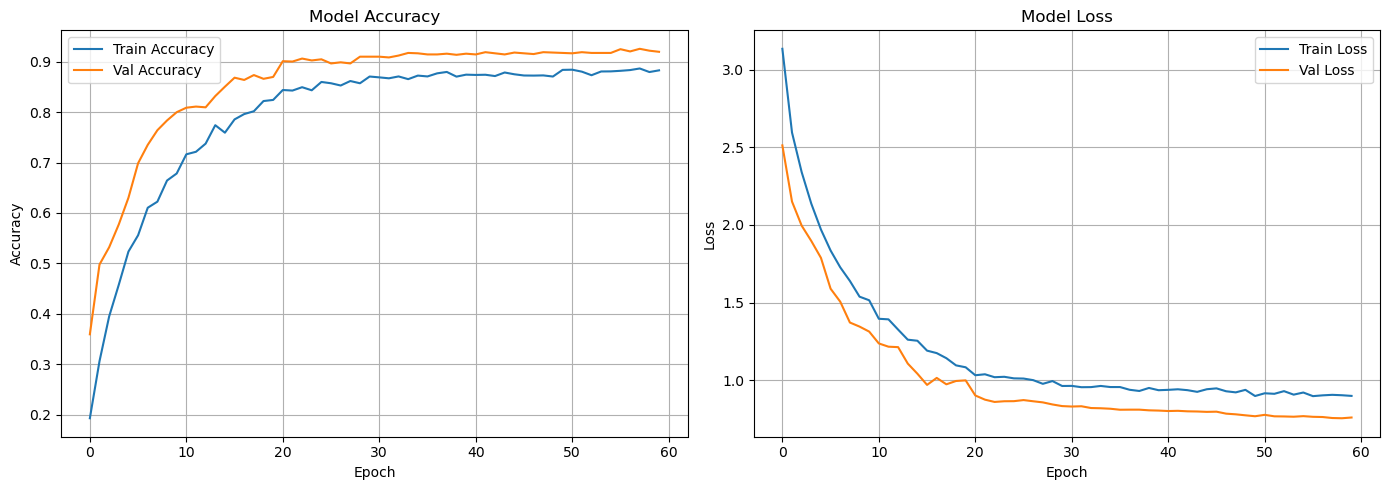

📊 Training curves saved to training_curves.png


In [8]:
def plot_training_history(history):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Accuracy
    axes[0].plot(history.history['accuracy'],     label='Train Accuracy')
    axes[0].plot(history.history['val_accuracy'], label='Val Accuracy')
    axes[0].set_title('Model Accuracy')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].grid(True)

    # Loss
    axes[1].plot(history.history['loss'],     label='Train Loss')
    axes[1].plot(history.history['val_loss'], label='Val Loss')
    axes[1].set_title('Model Loss')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(True)

    plt.tight_layout()
    plt.savefig('training_curves.png', dpi=150)
    plt.show()
    print("📊 Training curves saved to training_curves.png")

plot_training_history(history)



📊 Evaluating on validation set...

Classification Report:

                  precision    recall  f1-score   support

Banded Chlorosis       0.87      0.85      0.86        94
      Brown Spot       1.00      0.92      0.96       344
       BrownRust       0.70      1.00      0.82        62
    Dried Leaves       0.93      0.99      0.96        68
    Grassy shoot       1.00      0.96      0.98        69
  Healthy Leaves       0.92      0.98      0.95        86
    Pokkah Boeng       0.79      0.69      0.74        59
        Sett Rot       1.00      1.00      1.00       130
   Viral Disease       0.94      0.89      0.91       132
     Yellow Leaf       0.97      0.95      0.96       238
            smut       0.65      0.81      0.72        63

        accuracy                           0.92      1345
       macro avg       0.89      0.91      0.90      1345
    weighted avg       0.93      0.92      0.92      1345



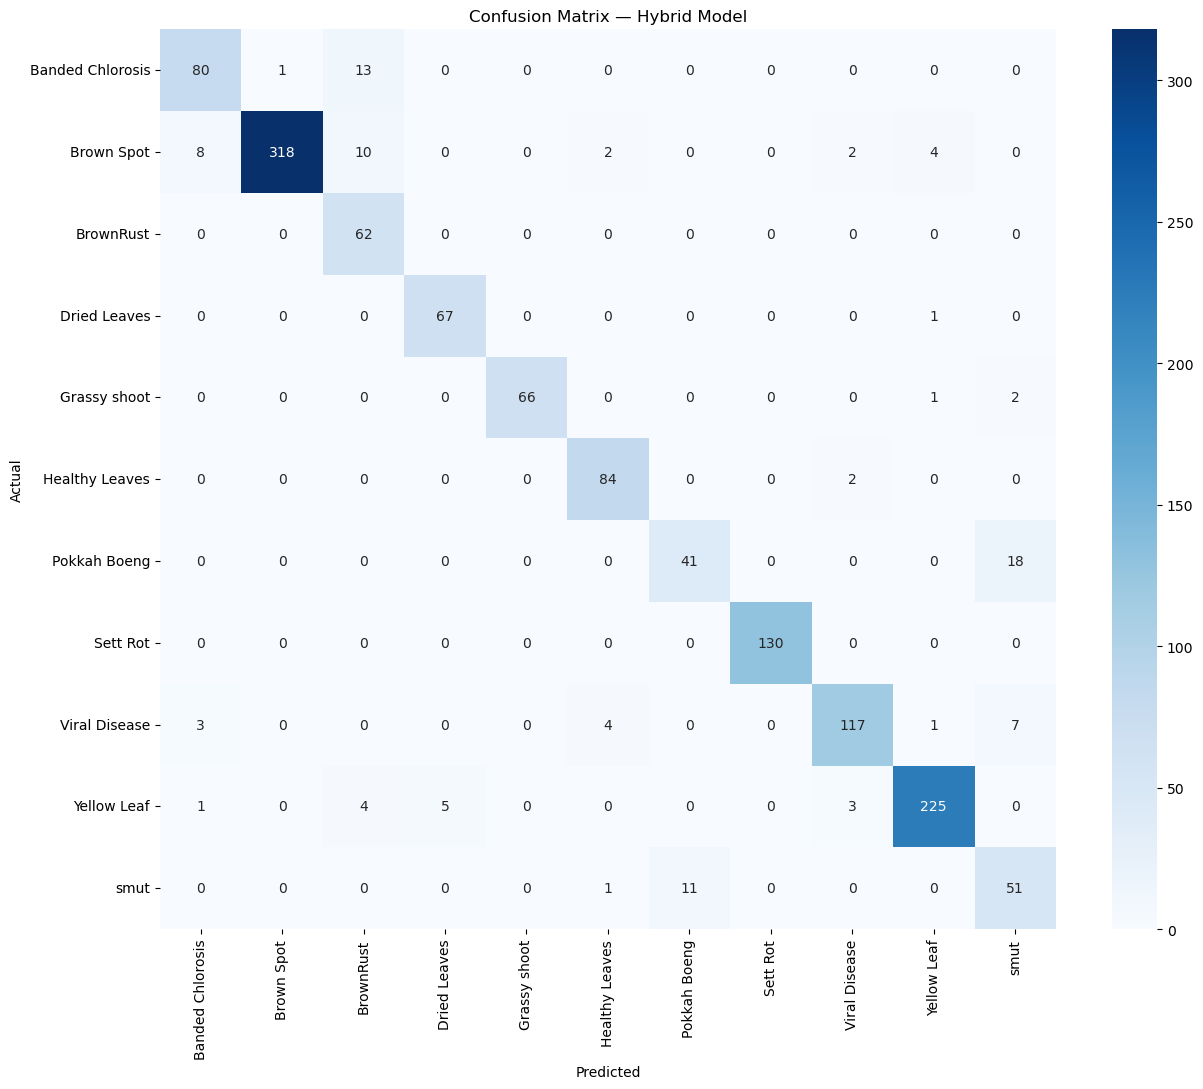


✅ Validation Accuracy: 92.27%


In [9]:
print("\n📊 Evaluating on validation set...")

# Collect all val predictions
all_preds  = []
all_labels = []

for i in range(len(val_hybrid)):
    inputs, labels = val_hybrid[i]
    preds = model.predict(inputs, verbose=0)
    all_preds.append(preds)
    all_labels.append(np.argmax(labels, axis=1))

y_pred = np.argmax(np.vstack(all_preds),  axis=1)
y_true = np.concatenate(all_labels)

# Trim to exact val size (last batch may be padded)
y_pred = y_pred[:val_gen.samples]
y_true = y_true[:val_gen.samples]

# Classification Report
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred,
                             target_names=class_labels,
                             zero_division=0))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(13, 11))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=class_labels,
            yticklabels=class_labels,
            cmap='Blues')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix — Hybrid Model')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

accuracy = np.sum(y_pred == y_true) / len(y_true)
print(f"\n✅ Validation Accuracy: {accuracy * 100:.2f}%")

     

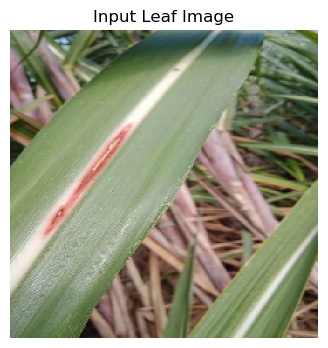


--- Stage 1: AI Leaf Analysis (top 3 candidates) ---
  Healthy Leaves           : 99.6%
  Viral Disease            : 0.2%
  Brown Spot               : 0.2%

--- Stem / Visual Symptom Check ---
Answer each question with 1 (Yes) or 0 (No):



  [Banded Chlorosis] Do you see alternating yellow/green horizontal bands on leaves? (1/0):  1
  [Brown Spot] Are there oval brown spots with yellow halos on the leaf surface? (1/0):  


  ⚠️  Invalid input. Enter 1 or 0.


  [Brown Spot] Are there oval brown spots with yellow halos on the leaf surface? (1/0):  1
  [BrownRust] Do you see powdery orange-brown pustules on the underside of leaves? (1/0):  1
  [Dried Leaves] Are the leaf tips or entire leaves dried out and brown/papery? (1/0):  1
  [Grassy shoot] Are there excessive thin, grass-like tillers/shoots at the base? (1/0):  0
  [Healthy Leaves] Does the plant look uniformly green with no visible spots or wilting? (1/0):  0
  [Pokkah Boeng] Is the top of the plant twisted, crinkled, or showing knife-cut lesions? (1/0):  0
  [Sett Rot] Is the inside of the cane reddish, hollow, or giving a foul smell? (1/0):  


  ⚠️  Invalid input. Enter 1 or 0.


  [Sett Rot] Is the inside of the cane reddish, hollow, or giving a foul smell? (1/0):  0
  [Viral Disease] Do you see mosaic/streaking patterns (mixed green-yellow patches) on leaves? (1/0):  0
  [Yellow Leaf] Is the midrib of the leaf turning bright yellow? (1/0):  0
  [smut] Do you see a whip-like black growth emerging from the top of the plant? (1/0):  1



✅ Final Hybrid Diagnosis : Healthy Leaves
   Confidence            : 99.5%


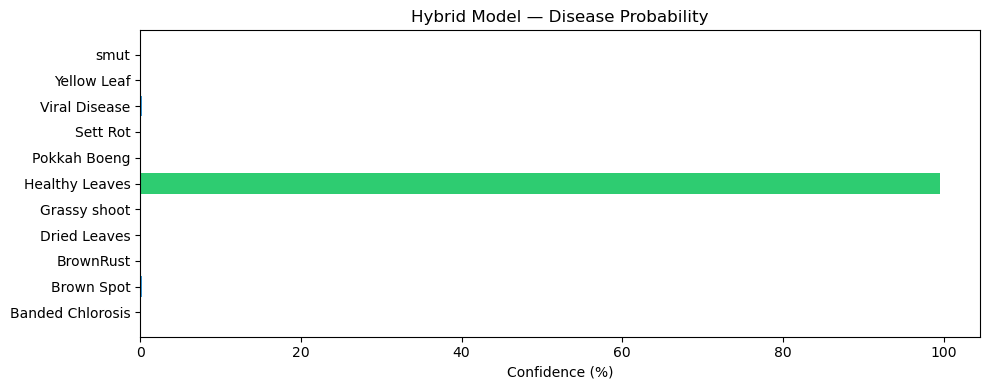

In [10]:
from tensorflow.keras.preprocessing import image as keras_image

def predict_disease(img_path, model_path='best_sugarcane_hybrid_model.h5'):
    """
    Full hybrid inference:
      1. Load image → leaf CNN branch
      2. Ask user binary symptom questions → stem branch
      3. Both branches feed into combined output → final diagnosis
    """
    # Load model
    loaded_model = tf.keras.models.load_model(model_path)

    # Load and preprocess image
    if not os.path.exists(img_path):
        print(f"❌ Image not found: {img_path}")
        return

    img       = keras_image.load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE))
    img_array = keras_image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)   # shape (1, 224, 224, 3)

    # Display image
    plt.figure(figsize=(4, 4))
    plt.imshow(keras_image.load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE)))
    plt.axis('off')
    plt.title("Input Leaf Image")
    plt.show()

    # ── Stage 1: Leaf-only preliminary prediction ───────────────────
    # Use neutral stem input (all 0.5) to see leaf-only confidence
    neutral_stem = np.full((1, NUM_STEM_FEATURES), 0.5, dtype=np.float32)
    leaf_preds   = loaded_model.predict(
        {"leaf_input": img_array, "stem_input": neutral_stem}, verbose=0
    )[0]
    top3_indices = leaf_preds.argsort()[-3:][::-1]

    print("\n--- Stage 1: AI Leaf Analysis (top 3 candidates) ---")
    for i in top3_indices:
        print(f"  {class_labels[i]:25s}: {leaf_preds[i]*100:.1f}%")

    # ── Stage 2: Collect real stem answers ──────────────────────────
    stem_data = get_stem_inputs_interactive()   # shape (1, 11)

    # ── Stage 3: Final hybrid prediction ────────────────────────────
    final_preds = loaded_model.predict(
        {"leaf_input": img_array, "stem_input": stem_data}, verbose=0
    )[0]
    final_index    = np.argmax(final_preds)
    final_disease  = class_labels[final_index]
    final_conf     = final_preds[final_index] * 100

    print(f"\n✅ Final Hybrid Diagnosis : {final_disease}")
    print(f"   Confidence            : {final_conf:.1f}%")

    # Show full probability bar chart
    plt.figure(figsize=(10, 4))
    colors = ['#2ecc71' if i == final_index else '#3498db'
              for i in range(num_classes)]
    plt.barh(class_labels, final_preds * 100, color=colors)
    plt.xlabel('Confidence (%)')
    plt.title('Hybrid Model — Disease Probability')
    plt.tight_layout()
    plt.savefig('prediction_result.png', dpi=150)
    plt.show()

    return final_disease, final_conf


# ── Run inference ────────────────────────────────────────────────────
if __name__ == "__main__":
    TEST_IMG = r"G:\study\MP3\test\test.jpeg"   # ← change to your test image
    result = predict_disease(TEST_IMG)
